# IoT Predictive Maintenance — Phase 1: Deep EDA

This notebook visualizes the raw vibration data and explains the **Feature Engineering** strategy used to distill 13GB of noise into a 1MB health model.

## 1. Loading the Raw Signal
We will load a single 10-second sample (320,000 points) from the Forward sensor.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Path to the unzipped NPY files
UNZIPPED_DIR = r'D:\IOT Project\Fan coil health model dataset\unzipped'

# Load 1 sample using mmap (memory mapping)
fwd_mmap = np.load(os.path.join(UNZIPPED_DIR, 'foward.npy'), mmap_mode='r')
sample_raw = fwd_mmap[0]

print(f"Loaded 1 sample with {len(sample_raw)} points.")

Loaded 1 sample with 320000 points.


## 2. Visualizing the 'Wall of Noise'
At 32,000 samples per second, 10 seconds of data is too dense to see any pattern at full scale.

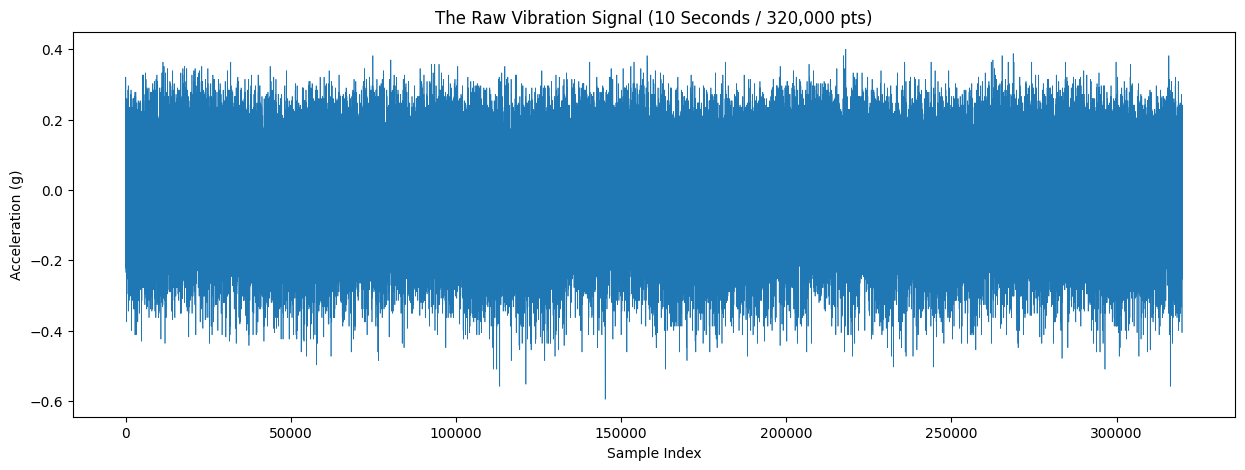

In [3]:
plt.figure(figsize=(15, 5))
plt.plot(sample_raw, color='#1f77b4', linewidth=0.5)
plt.title("The Raw Vibration Signal (10 Seconds / 320,000 pts)")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration (g)")
plt.show()

## 3. Zooming into the Physics
By zooming into a tiny slice (500 points), we see the actual oscillation of the motor.

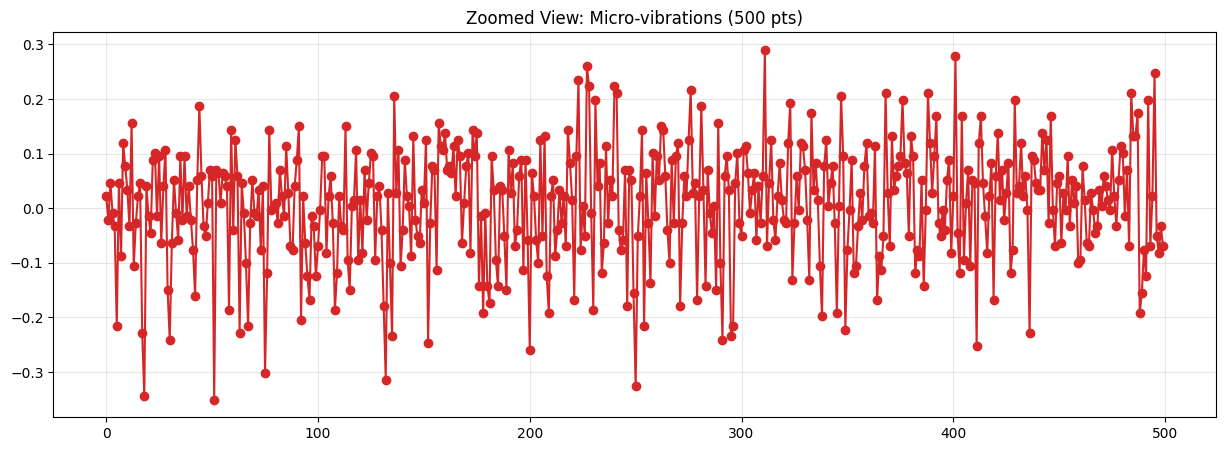

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(sample_raw[10000:10500], marker='o', color='#d62728')
plt.title("Zoomed View: Micro-vibrations (500 pts)")
plt.grid(alpha=0.3)
plt.show()

## 4. Feature Extraction Logic
We extract **14 physical features** to capture the 'soul' of this noise. 

| Feature | Purpose |
| :--- | :--- |
| **RMS Velocity** | Total vibration energy (Industry standard) |
| **Kurtosis** | Sharp impacts (Bearing failure) |
| **Skewness** | Asymmetrical rubbing (Misalignment) |
| **Std Dev** | Stability of the signal |

In [5]:
def extract_summary(data):
    return {
        'rms': np.sqrt(np.mean(np.cumsum(data)**2 / 32000 * 1000)),
        'kurtosis': stats.kurtosis(data),
        'skew': stats.skew(data),
        'max': np.max(data)
    }

print("Sample Feature Extraction Result:")
print(extract_summary(sample_raw))

Sample Feature Extraction Result:
{'rms': 27.837715, 'kurtosis': 0.2871469126009014, 'skew': -0.29823977916290834, 'max': 0.4002161}


## Conclusion
This extraction process reduces the data volume by **22,000x**, removing high-frequency noise and keeping only the maintenance-relevant metrics.